# EDA & Risk Forecasting — GDELT Bénin 2025

**Objectif** : prédire à 7 jours, par département, la probabilité d'un événement grave (Goldstein ≤ -5).

**Pipeline** :
1. Chargement & nettoyage des données GDELT
2. Feature engineering (lags, rolling, encodage)
3. Construction de la target FUTURE (anti-leakage)
4. Modèle Random Forest + baseline
5. Évaluation business (precision, recall, lift)
6. Carte interactive Folium des hotspots

**Approche anti-leakage** : la target regarde les 7 jours suivants, les features regardent uniquement le passé.

## 0. Imports & Connexion BigQuery

In [1]:
import os
import hashlib
from pathlib import Path

import pandas as pd
import numpy as np
import pandas_gbq
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

PROJECT_ID = "gdelt-494812"
DATASET_ID = "benin_2025"
KEY_PATH = "gdelt-494812-e7b391e14150.json"

os.makedirs("cache", exist_ok=True)
os.makedirs("cachemodels", exist_ok=True)

def get_credentials():
    if os.path.exists(KEY_PATH):
        from google.oauth2 import service_account
        return service_account.Credentials.from_service_account_file(
            KEY_PATH,
            scopes=["https://www.googleapis.com/auth/cloud-platform"]
        )
    return None

credentials = get_credentials()

if credentials is not None:
    print("✓ Service account credentials loaded")
    print(f"  Key file: {Path(KEY_PATH).resolve()}")
else:
    print("❌ JSON key file not found")
    print(f"  Expected path: {Path(KEY_PATH).resolve()}")

✓ Service account credentials loaded
  Key file: /home/charly/Desktop/GDELT Project/notebooks/gdelt-494812-e7b391e14150.json


In [2]:
def charger_donnees(query, force_reload=False):
    query_hash = hashlib.md5(query.encode("utf-8")).hexdigest()[:8]
    cache_path = f"cache/cache_{query_hash}.csv"

    if os.path.exists(cache_path) and not force_reload:
        df = pd.read_csv(cache_path)
        print(f"✓ Loaded from cache: {cache_path}")
    else:
        df = pandas_gbq.read_gbq(
            query,
            project_id=PROJECT_ID,
            credentials=credentials,
            dialect="standard"
        )
        df.to_csv(cache_path, index=False)
        print(f"✓ Loaded from BigQuery and cached: {cache_path}")

    return df

## 1. Chargement des données brutes

In [3]:
query_schema = f"""
SELECT
  column_name,
  data_type
FROM `{PROJECT_ID}.{DATASET_ID}.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name = 'events_clean'
ORDER BY ordinal_position
"""

df_schema = charger_donnees(query_schema, force_reload=True)
df_schema

Downloading: 100%|██████████|
✓ Loaded from BigQuery and cached: cache/cache_ffec28db.csv


,column_name,data_type
0,GLOBALEVENTID,INT64
1,DATEADDED,INT64
2,SQLDATE,INT64
3,MonthYear,INT64
4,Year,INT64
5,Actor1Name,STRING
6,Actor1CountryCode,STRING
7,Actor1Type1Code,STRING
8,Actor2Name,STRING
9,Actor2CountryCode,STRING


In [4]:
query_ml = f"""
SELECT
  GLOBALEVENTID,
  date_clean,
  year_month_clean,
  EventRootCode,
  EventCode,
  QuadClass,
  QuadClass_Label,
  interaction_type,
  GoldsteinScale,
  goldstein_category,
  AvgTone,
  tone_category,
  NumMentions,
  Actor1Type1Code,
  Actor1Role,
  Actor2Type1Code,
  Actor2Role,
  ActionGeo_CountryCode,
  ActionGeo_ADM1Code,
  ActionGeo_Lat,
  ActionGeo_Long,
  has_international_actor,
  event_scope,
  is_significant
FROM `{PROJECT_ID}.{DATASET_ID}.events_clean`
ORDER BY date_clean DESC
"""

df_ml = charger_donnees(query_ml)
print(f"✓ {len(df_ml):,} événements chargés pour ML")

✓ Loaded from cache: cache/cache_b3e66038.csv
✓ 31,504 événements chargés pour ML


## 2. Nettoyage & construction de la target

⚠️ **Point clé anti-leakage** : la cible `target` regarde les 7 jours **suivants** (futur), pas l'événement actuel. C'est ce qui rend le modèle utile : on **anticipe** au lieu de re-classifier le passé.

In [5]:
df = df_ml.copy()

# Conversion datetime + features calendaires
df['date'] = pd.to_datetime(df['date_clean'])
df['month'] = df['date'].dt.month
df['dow'] = df['date'].dt.dayofweek
df['week'] = df['date'].dt.isocalendar().week

# Typage strict des numériques
numeric_cols = ['GoldsteinScale', 'AvgTone', 'NumMentions', 'ActionGeo_Lat', 'ActionGeo_Long']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Risk Score descriptif (pour visualisations EDA seulement, PAS pour le modèle)
df['risk_raw'] = -df['GoldsteinScale']
df['risk_level'] = pd.cut(
    df['risk_raw'],
    bins=[-np.inf, -5, -2, 2, 5, np.inf],
    labels=['Très positif', 'Positif', 'Neutre', 'Négatif', 'Très négatif']
)

df['quadclass_name'] = df['QuadClass_Label']
df['is_conflict'] = (df['QuadClass'] >= 3).astype(int)  # gardé pour EDA

# ───────────────────────────────────────────────────────────
# 🎯 TARGET FUTURE — pas de leakage
# Pour chaque événement : y a-t-il un Goldstein ≤ -5 dans les 7 jours suivants ?
# ───────────────────────────────────────────────────────────
df = df.sort_values(['ActionGeo_ADM1Code', 'date']).reset_index(drop=True)

df['goldstein_min_next_7d'] = (
    df.groupby('ActionGeo_ADM1Code')['GoldsteinScale']
      .shift(-1)                            # décale d'1 jour vers le futur
      .rolling(7, min_periods=1).min()      # min sur 7 jours futurs
      .reset_index(level=0, drop=True)
)

df['target'] = (df['goldstein_min_next_7d'] <= -5).astype(int)

# Géolocalisation — QC basique
df_geo = df[
    (df['ActionGeo_Lat'].notna()) &
    (df['ActionGeo_Long'].notna()) &
    (df['ActionGeo_Lat'] != 0) &
    (df['ActionGeo_Long'] != 0)
].copy()

print(f'✓ Nettoyage terminé')
print(f'  Lignes complètes        : {len(df):,}')
print(f'  Événements géolocalisés : {len(df_geo):,} ({100*len(df_geo)/len(df):.1f}%)')
print(f'  Risk Score range        : [{df["risk_raw"].min():.1f}, {df["risk_raw"].max():.1f}]')
print(f'  Target=1 (conflit J+7)  : {df["target"].sum():,} ({100*df["target"].mean():.1f}%)')

✓ Nettoyage terminé
  Lignes complètes        : 31,504
  Événements géolocalisés : 31,464 (99.9%)
  Risk Score range        : [-10.0, 10.0]
  Target=1 (conflit J+7)  : 18,448 (58.6%)


## 3. Feature Engineering

Toutes les features regardent **uniquement le passé** (`shift`, `rolling` sur historique). Aucun leakage.

In [6]:
from sklearn.preprocessing import LabelEncoder

# Le tri a déjà été fait à la cellule précédente
# (par ActionGeo_ADM1Code, date)

# 1. Lag features Goldstein (passé)
df['goldstein_lag_7d']  = df.groupby('ActionGeo_ADM1Code')['GoldsteinScale'].shift(7)
df['goldstein_lag_14d'] = df.groupby('ActionGeo_ADM1Code')['GoldsteinScale'].shift(14)

# 2. Rolling means (tendance passée)
df['goldstein_roll_7d'] = (
    df.groupby('ActionGeo_ADM1Code')['GoldsteinScale']
      .rolling(7, min_periods=1).mean()
      .reset_index(level=0, drop=True)
)
df['goldstein_roll_30d'] = (
    df.groupby('ActionGeo_ADM1Code')['GoldsteinScale']
      .rolling(30, min_periods=1).mean()
      .reset_index(level=0, drop=True)
)

# 3. Volume événements 7j (par région)
df['event_count_7d'] = (
    df.groupby('ActionGeo_ADM1Code')['GLOBALEVENTID']
      .rolling(7, min_periods=1).count()
      .reset_index(level=0, drop=True)
)

# 4. Saisonnalité (encodage cyclique du mois)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# 5. Encodage des acteurs (Label Encoding)
le_actor1 = LabelEncoder()
le_actor2 = LabelEncoder()
le_event  = LabelEncoder()

df['Actor1Type1Code_enc'] = le_actor1.fit_transform(df['Actor1Type1Code'].fillna('UNK').astype(str))
df['Actor2Type1Code_enc'] = le_actor2.fit_transform(df['Actor2Type1Code'].fillna('UNK').astype(str))
df['EventRootCode_enc']   = le_event.fit_transform(df['EventRootCode'].fillna('UNK').astype(str))

# Vérification finale
new_features = [
    'Actor1Type1Code_enc', 'Actor2Type1Code_enc',
    'goldstein_lag_7d', 'goldstein_lag_14d',
    'goldstein_roll_7d', 'goldstein_roll_30d',
    'month_sin', 'month_cos', 'event_count_7d'
]

missing = [f for f in new_features if f not in df.columns]
if missing:
    print(f"❌ Manquant : {missing}")
else:
    print(f"✅ Toutes les features sont créées :")
    for f in new_features:
        print(f"   - {f}")
    print(f"\nNaN par feature :")
    print(df[new_features].isna().sum())

✅ Toutes les features sont créées :
   - Actor1Type1Code_enc
   - Actor2Type1Code_enc
   - goldstein_lag_7d
   - goldstein_lag_14d
   - goldstein_roll_7d
   - goldstein_roll_30d
   - month_sin
   - month_cos
   - event_count_7d

NaN par feature :
Actor1Type1Code_enc       0
Actor2Type1Code_enc       0
goldstein_lag_7d       1658
goldstein_lag_14d      2482
goldstein_roll_7d        37
goldstein_roll_30d       37
month_sin                 0
month_cos                 0
event_count_7d           37
dtype: int64


## 4. Split train/test temporel

In [7]:
# Features finales du modèle
features = [
    'Actor1Type1Code_enc',
    'Actor2Type1Code_enc',
    'AvgTone',
    'NumMentions',
    'goldstein_lag_7d',
    'goldstein_lag_14d',
    'goldstein_roll_7d',
    'goldstein_roll_30d',
    'month_sin',
    'month_cos',
    'event_count_7d'
]

# Filtrer les lignes complètes
df_model = df.dropna(subset=features + ['target']).copy()

X = df_model[features]
y = df_model['target']

# Split temporel (80% train, 20% test)
split_date = df_model['date'].quantile(0.8)
train_mask = df_model['date'] < split_date

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[~train_mask], y[~train_mask]

# Diagnostic
events_lost = len(df) - len(df_model)
total_ml = len(X_train) + len(X_test)

print(f"✓ Données préparées pour ML")
print(f"  Total df : {len(df):,} événements")
print(f"  - Perdus (NaN features)  : {events_lost:,} ({100*events_lost/len(df):.1f}%)")
print(f"  - ML (complets)          : {len(df_model):,} → {total_ml:,} (train+test)")
print(f"")
print(f"  Train : {len(X_train):,} ({df_model[train_mask]['date'].min().date()} → {df_model[train_mask]['date'].max().date()})")
print(f"  Test  : {len(X_test):,} ({df_model[~train_mask]['date'].min().date()} → {df_model[~train_mask]['date'].max().date()})")
print(f"")
print(f"  Ratio target=1 (train) : {y_train.mean():.1%}")
print(f"  Ratio target=1 (test)  : {y_test.mean():.1%}")

✓ Données préparées pour ML
  Total df : 31,504 événements
  - Perdus (NaN features)  : 2,482 (7.9%)
  - ML (complets)          : 29,022 → 29,022 (train+test)

  Train : 23,191 (2025-01-01 → 2025-11-26)
  Test  : 5,831 (2025-11-27 → 2025-12-31)

  Ratio target=1 (train) : 58.3%
  Ratio target=1 (test)  : 67.8%


## 5. Modèle Random Forest + baseline

On compare le modèle ML à une **baseline naïve** ("le passé immédiat prédit le futur") pour prouver que le modèle apporte vraiment de la valeur.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
import joblib

# Entraînement
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=50,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

# Prédictions
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

# ───────────────────────────────────────────────────────────
# Baseline naïve
# ───────────────────────────────────────────────────────────
baseline_pred = (X_test['goldstein_roll_30d'] <= -2).astype(int)

# Métriques
f1_rf        = f1_score(y_test, y_pred)
f1_base      = f1_score(y_test, baseline_pred)
auc_rf       = roc_auc_score(y_test, y_proba)
precision_rf = precision_score(y_test, y_pred)
recall_rf    = recall_score(y_test, y_pred)

print("=" * 60)
print("  ÉVALUATION — prédiction conflit grave J+1 à J+7")
print("=" * 60)
print(f"  F1 modèle     : {f1_rf:.3f}")
print(f"  F1 baseline   : {f1_base:.3f}")
print(f"  Lift modèle   : +{(f1_rf - f1_base)*100:.1f} pts vs baseline")
print(f"")
print(f"  ROC-AUC       : {auc_rf:.3f}")
print(f"  Precision     : {precision_rf:.3f}  (sur les alertes émises, % de vraies)")
print(f"  Recall        : {recall_rf:.3f}  (sur les vrais conflits, % détectés)")
print("=" * 60)

# Sauvegarde
joblib.dump(rf,       'cachemodels/risk_model.pkl')
joblib.dump(features, 'cachemodels/features.pkl')
joblib.dump(le_event, 'cachemodels/le_event.pkl')
joblib.dump(le_actor1,'cachemodels/le_actor1.pkl')
joblib.dump(le_actor2,'cachemodels/le_actor2.pkl')

print("\n✓ Modèle entraîné et sauvegardé")

  ÉVALUATION — prédiction conflit grave J+1 à J+7
  F1 modèle     : 0.820
  F1 baseline   : 0.129
  Lift modèle   : +69.1 pts vs baseline

  ROC-AUC       : 0.828
  Precision     : 0.848  (sur les alertes émises, % de vraies)
  Recall        : 0.794  (sur les vrais conflits, % détectés)

✓ Modèle entraîné et sauvegardé


## 6. Matrice de confusion + lecture business

ÉVALUATION DU MODÈLE — Conflit grave J+1 à J+7
                       precision    recall  f1-score   support

 Pas de conflit grave       0.62      0.70      0.66      1876
Conflit grave attendu       0.85      0.79      0.82      3955

             accuracy                           0.76      5831
            macro avg       0.73      0.75      0.74      5831
         weighted avg       0.77      0.76      0.77      5831



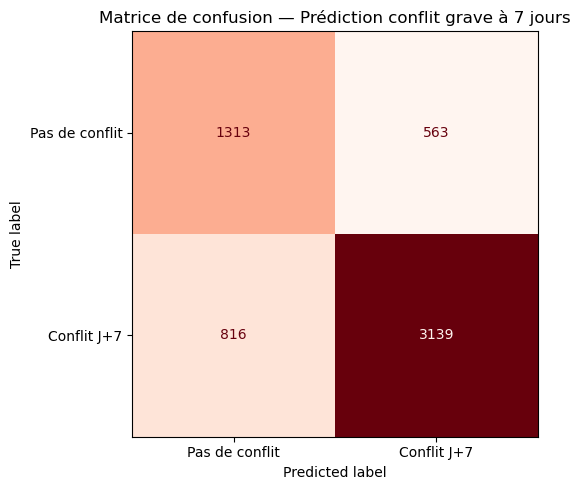


  LECTURE BUSINESS — comme un préfet le verrait
  ✓ Vrais positifs (alertes justes)     : 3139
  ✗ Faux positifs (fausses alertes)     :  563
  ✗ Faux négatifs (conflits ratés)      :  816
  ✓ Vrais négatifs (calme bien prédit)  : 1313

  → Sur 100 alertes émises, 85 sont des vrais conflits
  → Sur 100 vrais conflits, 79 sont détectés à l'avance


In [9]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("=" * 60)
print("ÉVALUATION DU MODÈLE — Conflit grave J+1 à J+7")
print("=" * 60)
print(classification_report(
    y_test, y_pred,
    target_names=["Pas de conflit grave", "Conflit grave attendu"]
))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Pas de conflit", "Conflit J+7"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Reds", colorbar=False)
ax.set_title("Matrice de confusion — Prédiction conflit grave à 7 jours")
plt.tight_layout()
plt.show()

# Lecture business
tn, fp, fn, tp = cm.ravel()
total_alertes = tp + fp
total_vrais   = tp + fn

print("\n" + "=" * 60)
print("  LECTURE BUSINESS — comme un préfet le verrait")
print("=" * 60)
print(f"  ✓ Vrais positifs (alertes justes)     : {tp:4d}")
print(f"  ✗ Faux positifs (fausses alertes)     : {fp:4d}")
print(f"  ✗ Faux négatifs (conflits ratés)      : {fn:4d}")
print(f"  ✓ Vrais négatifs (calme bien prédit)  : {tn:4d}")
print(f"")
if total_alertes > 0:
    print(f"  → Sur 100 alertes émises, {100*tp/total_alertes:.0f} sont des vrais conflits")
if total_vrais > 0:
    print(f"  → Sur 100 vrais conflits, {100*tp/total_vrais:.0f} sont détectés à l'avance")
print("=" * 60)

## 7. Feature importance — ce que le modèle apprend

In [10]:
feat_imp = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# Renommage lisible
feature_labels = {
    'Actor1Type1Code_enc': 'Type acteur 1',
    'Actor2Type1Code_enc': 'Type acteur 2',
    'AvgTone': 'Tonalité presse',
    'NumMentions': 'Nb mentions presse',
    'goldstein_lag_7d': 'Goldstein J-7',
    'goldstein_lag_14d': 'Goldstein J-14',
    'goldstein_roll_7d': 'Moyenne Goldstein 7j',
    'goldstein_roll_30d': 'Moyenne Goldstein 30j',
    'month_sin': 'Saisonnalité (sin)',
    'month_cos': 'Saisonnalité (cos)',
    'event_count_7d': 'Volume événements 7j',
}
feat_imp['feature_label'] = feat_imp['feature'].map(feature_labels).fillna(feat_imp['feature'])

fig_imp = px.bar(
    feat_imp,
    x='importance',
    y='feature_label',
    orientation='h',
    title='<b>Quels signaux prédisent un conflit grave à 7 jours ?</b>',
    height=480,
    color='importance',
    color_continuous_scale='Reds',
    text=feat_imp['importance'].apply(lambda x: f'{x*100:.1f}%')
)
fig_imp.update_layout(
    yaxis={'categoryorder': 'total ascending', 'title': ''},
    xaxis={'title': 'Importance relative'},
    showlegend=False,
    coloraxis_showscale=False,
    template='plotly_white',
)
fig_imp.update_traces(textposition='outside')
fig_imp.show()

# Insight pour le pitch
top1 = feat_imp.iloc[0]
top3 = feat_imp.head(3)['feature_label'].tolist()

print("\n" + "=" * 60)
print("  TOP FEATURES — l'histoire que raconte le modèle")
print("=" * 60)
print(feat_imp[['feature_label', 'importance']].head(10).to_string(index=False))
print("=" * 60)
print(f"\n→ Signal #1 : {top1['feature_label']} ({top1['importance']*100:.1f}%)")
print(f"→ Top 3     : {', '.join(top3)}")


  TOP FEATURES — l'histoire que raconte le modèle
        feature_label  importance
 Moyenne Goldstein 7j    0.648072
Moyenne Goldstein 30j    0.181707
      Tonalité presse    0.067573
        Goldstein J-7    0.026128
       Goldstein J-14    0.018714
        Type acteur 1    0.014131
   Saisonnalité (sin)    0.012700
   Nb mentions presse    0.011482
   Saisonnalité (cos)    0.010427
        Type acteur 2    0.009066

→ Signal #1 : Moyenne Goldstein 7j (64.8%)
→ Top 3     : Moyenne Goldstein 7j, Moyenne Goldstein 30j, Tonalité presse


## 8. Carte interactive — hotspots prédits

Carte Folium avec heatmap + marqueurs proportionnels au volume d'événements. Chaque département est colorié selon la **probabilité prédite** de conflit grave dans les 7 prochains jours.

In [11]:
# Installation Folium (commenter si déjà installé)
# !pip install folium --quiet

import folium
from folium.plugins import HeatMap

# ───────────────────────────────────────────────────────────
# 1. Préparation des hotspots
# ───────────────────────────────────────────────────────────
df_test_pred = df_model.loc[~train_mask].copy()
df_test_pred["risk_proba"] = y_proba
df_test_pred["y_pred"]     = y_pred

# Fusionner BN générique avec BN00
df_test_pred["ActionGeo_ADM1Code"] = df_test_pred["ActionGeo_ADM1Code"].replace({"BN": "BN00"})

# Agrégation par département
hotspots = (
    df_test_pred
    .dropna(subset=["ActionGeo_ADM1Code", "ActionGeo_Lat", "ActionGeo_Long"])
    .groupby("ActionGeo_ADM1Code", as_index=False)
    .agg(
        risk_score=("risk_proba", "mean"),
        event_count=("GLOBALEVENTID", "count"),
        lat=("ActionGeo_Lat", "median"),
        lon=("ActionGeo_Long", "median")
    )
)

hotspots["risk_category"] = pd.cut(
    hotspots["risk_score"],
    bins=[0, 0.33, 0.66, 1.0],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

print(f"✅ Hotspots créés : {len(hotspots)} régions")

# ───────────────────────────────────────────────────────────
# 2. Filtrer Bénin + nommer les départements
# ───────────────────────────────────────────────────────────
hotspots_benin = hotspots[hotspots["ActionGeo_ADM1Code"].str.startswith("BN", na=False)].copy()
df_map = hotspots_benin[hotspots_benin["ActionGeo_ADM1Code"] != "BN00"].copy()

dept_names = {
    "BN07": "Alibori", "BN08": "Atakora", "BN09": "Atlantique",
    "BN10": "Borgou", "BN11": "Collines", "BN12": "Kouffo",
    "BN13": "Donga", "BN14": "Littoral (Cotonou)", "BN15": "Mono",
    "BN16": "Ouémé (Porto-Novo)", "BN17": "Plateau", "BN18": "Zou",
    "BN00": "Bénin (non localisé)"
}
df_map["dept_name"] = df_map["ActionGeo_ADM1Code"].map(dept_names).fillna(df_map["ActionGeo_ADM1Code"])

COLOR_LOW, COLOR_MED, COLOR_HIGH = "#27ae60", "#f39c12", "#e74c3c"
df_map["risk_category_str"] = df_map["risk_category"].astype(str)
df_map["color"] = df_map["risk_category_str"].map({
    "Low": COLOR_LOW, "Medium": COLOR_MED, "High": COLOR_HIGH
}).fillna("#888888")

# ───────────────────────────────────────────────────────────
# 3. Carte Folium
# ───────────────────────────────────────────────────────────
center_lat = df_map["lat"].median()
center_lon = df_map["lon"].median()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=7,
    tiles="OpenStreetMap",
    prefer_canvas=True,
)

# Heatmap
heat_data = [[row["lat"], row["lon"], row["risk_score"]] for _, row in df_map.iterrows()]
HeatMap(
    heat_data,
    radius=20, blur=18, min_opacity=0.3,
    gradient={"0.0": "#27ae60", "0.33": "#f39c12", "0.66": "#e74c3c", "1.0": "#c0392b"},
).add_to(m)

# Marqueurs circulaires
for _, row in df_map.iterrows():
    radius = max(6, min(row["event_count"] * 0.8, 40))
    risk_label = row["risk_category_str"]

    popup_html = f"""
    <div style="font-family:Inter,sans-serif;min-width:220px;">
        <b style="font-size:15px;color:#1f2937;">{row['dept_name']}</b><br>
        <span style="font-size:10px;color:#9ca3af;">{row['ActionGeo_ADM1Code']}</span>
        <hr style="margin:6px 0;border-color:#e5e7eb;">
        <b style="color:{row['color']};font-size:13px;">Risque {risk_label}</b><br>
        <div style="margin-top:6px;color:#6b7280;font-size:12px;">
            <b>{int(row['event_count'])}</b> événements analysés<br>
            Probabilité conflit J+7 : <b style="color:{row['color']};">{row['risk_score']:.1%}</b>
        </div>
    </div>
    """

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=radius,
        color="white", weight=1.5,
        fill=True, fill_color=row["color"], fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=260),
        tooltip=f"{row['dept_name']} — Risque J+7 : {row['risk_score']:.1%}",
    ).add_to(m)

# ───────────────────────────────────────────────────────────
# 4. Légende
# ───────────────────────────────────────────────────────────
stats_by_risk = df_map.groupby("risk_category", observed=False).agg({
    "ActionGeo_ADM1Code": "count",
    "risk_score": "mean",
    "event_count": "sum"
}).reset_index()

bn00_data = hotspots_benin[hotspots_benin["ActionGeo_ADM1Code"] == "BN00"]
if len(bn00_data) > 0:
    bn00_row = bn00_data.iloc[0]
    bn00_events = int(bn00_row["event_count"])
    bn00_risk = bn00_row["risk_score"]
    bn00_category = str(bn00_row["risk_category"])
else:
    bn00_events, bn00_risk, bn00_category = 0, 0, "N/A"

stats_rows_html = ""
for risk_level in ["High", "Medium", "Low"]:
    matching = stats_by_risk[stats_by_risk["risk_category"].astype(str) == risk_level]
    if len(matching) > 0:
        r = matching.iloc[0]
        nb_regions = int(r["ActionGeo_ADM1Code"])
        avg_risk = r["risk_score"]
        total_events = int(r["event_count"])
        color = {"High": "#e74c3c", "Medium": "#f39c12", "Low": "#27ae60"}[risk_level]
        stats_rows_html += f"""
        <tr>
            <td style="padding:4px 8px;font-size:11px;font-weight:600;color:{color};">{risk_level}</td>
            <td style="padding:4px 8px;font-size:11px;text-align:center;">{nb_regions}</td>
            <td style="padding:4px 8px;font-size:11px;text-align:center;color:{color};font-weight:700;">{avg_risk:.1%}</td>
            <td style="padding:4px 8px;font-size:11px;text-align:center;">{total_events}</td>
        </tr>"""

if bn00_events > 0:
    stats_rows_html += f"""
        <tr style="background:#f9fafb;border-top:1px dashed #d1d5db;">
            <td colspan="4" style="padding:4px 8px;font-size:10px;color:#6b7280;font-style:italic;">
                + Événements non localisés : <b>{bn00_events}</b> évts ({bn00_risk:.1%} risk)
            </td>
        </tr>"""

top_regions = df_map.sort_values("risk_score", ascending=False).head(3)
top_regions_html = ""
for _, row in top_regions.iterrows():
    color_display = row["color"]
    top_regions_html += f"""
    <tr style="background:#fff5f5;">
        <td style="padding:4px 8px;font-size:11px;font-weight:600;color:{color_display};">{row['dept_name']}</td>
        <td style="padding:4px 8px;font-size:11px;text-align:center;color:{color_display};font-weight:700;">{row['risk_score']:.1%}</td>
        <td style="padding:4px 8px;font-size:11px;text-align:center;">{int(row['event_count'])}</td>
    </tr>"""

legend_html = f"""
<div style="position:fixed; bottom:30px; left:30px; z-index:9999;
    background:rgba(255,255,255,0.97); color:#1f2937;
    padding:16px 20px; border-radius:12px;
    font-family:Inter,sans-serif; font-size:13px;
    border:1px solid #e5e7eb; box-shadow:0 4px 20px rgba(0,0,0,0.15);
    max-width:320px;">
    <b style="font-size:15px;display:block;margin-bottom:10px;">
        🇧🇯 Risque prédit J+7 — Bénin 2025
    </b>
    <span style="color:#27ae60;font-size:18px;">●</span>&nbsp;Low Risk<br>
    <span style="color:#f39c12;font-size:18px;">●</span>&nbsp;Medium Risk<br>
    <span style="color:#e74c3c;font-size:18px;">●</span>&nbsp;High Risk<br>
    <div style="margin-top:10px;padding-top:10px;border-top:1px solid #e5e7eb;
                color:#6b7280;font-size:11px;line-height:1.5;">
        <b>Modèle ML :</b> Random Forest (forecasting 7j)<br>
        Probabilité d'un événement grave dans les 7 prochains jours<br>
        Taille = volume d'événements observés<br>
        Cliquer sur un point pour les détails
    </div>
    <div style="margin-top:12px;padding-top:10px;border-top:1px solid #e5e7eb;">
        <b style="font-size:12px;color:#374151;">Répartition par niveau de risque</b>
        <table style="width:100%;margin-top:8px;border-collapse:collapse;">
            <thead><tr style="background:#f9fafb;">
                <th style="padding:4px 8px;font-size:10px;text-align:left;color:#6b7280;">Niveau</th>
                <th style="padding:4px 8px;font-size:10px;text-align:center;color:#6b7280;">Dép.</th>
                <th style="padding:4px 8px;font-size:10px;text-align:center;color:#6b7280;">Risque</th>
                <th style="padding:4px 8px;font-size:10px;text-align:center;color:#6b7280;">Évts</th>
            </tr></thead>
            <tbody>{stats_rows_html}</tbody>
        </table>
    </div>
    <div style="margin-top:12px;padding-top:10px;border-top:1px solid #e5e7eb;">
        <b style="font-size:12px;color:#e74c3c;">🔴 Top 3 départements sensibles</b>
        <table style="width:100%;margin-top:8px;border-collapse:collapse;">
            <thead><tr style="background:#fff5f5;">
                <th style="padding:4px 8px;font-size:10px;text-align:left;color:#e74c3c;">Département</th>
                <th style="padding:4px 8px;font-size:10px;text-align:center;color:#e74c3c;">Risk</th>
                <th style="padding:4px 8px;font-size:10px;text-align:center;color:#e74c3c;">Évts</th>
            </tr></thead>
            <tbody>{top_regions_html}</tbody>
        </table>
    </div>
    <div style="margin-top:10px;font-size:9px;color:#9ca3af;font-style:italic;text-align:center;">
        Early Warning System — ML Prediction<br>
        {len(df_map)} départements analysés
    </div>
</div>
"""

m.get_root().html.add_child(folium.Element(legend_html))

# Export
m.save("cachemodels/risk_hotspot_map_benin_2025.html")
print(f"✅ Carte exportée : cachemodels/risk_hotspot_map_benin_2025.html")
print(f"   {len(df_map)} départements visibles")
print(f"   {bn00_events} événements non localisés (en légende)")

# Top régions à surveiller (pour le résumé d'une page)
print("\n🚨 RÉGIONS À SURVEILLER CETTE SEMAINE :")
for i, (_, row) in enumerate(top_regions.iterrows(), 1):
    print(f"   {i}. {row['dept_name']:25s} → {row['risk_score']:.1%} de risque ({int(row['event_count'])} évts)")

m

✅ Hotspots créés : 71 régions
✅ Carte exportée : cachemodels/risk_hotspot_map_benin_2025.html
   8 départements visibles
   4235 événements non localisés (en légende)

🚨 RÉGIONS À SURVEILLER CETTE SEMAINE :
   1. Atakora                   → 78.1% de risque (10 évts)
   2. Borgou                    → 73.0% de risque (25 évts)
   3. Alibori                   → 59.7% de risque (2 évts)


## 9. Sauvegarde des artefacts pour la phase 2

In [12]:
feat_imp.to_csv('cachemodels/feature_importance.csv', index=False)
hotspots.to_csv('cachemodels/hotspots.csv', index=False)
df_test_pred[['date', 'ActionGeo_ADM1Code', 'risk_proba', 'y_pred']].to_csv(
    'cachemodels/test_predictions.csv', index=False
)

print("✓ Artifacts sauvegardés dans cachemodels/")
print("  - risk_model.pkl")
print("  - features.pkl")
print("  - le_event.pkl, le_actor1.pkl, le_actor2.pkl")
print("  - feature_importance.csv")
print("  - hotspots.csv")
print("  - test_predictions.csv")
print("  - risk_hotspot_map_benin_2025.html")

✓ Artifacts sauvegardés dans cachemodels/
  - risk_model.pkl
  - features.pkl
  - le_event.pkl, le_actor1.pkl, le_actor2.pkl
  - feature_importance.csv
  - hotspots.csv
  - test_predictions.csv
  - risk_hotspot_map_benin_2025.html
